# Ultralytics YOLO26s · AI Hub 알약 객체 탐지

약 10,000장 / 118종 조합 데이터용 학습·평가·제출 파이프라인입니다.

- AI Hub partial JSON을 이미지 단위로 병합하고 `dl_mapping_code`를 클래스 라벨로 사용합니다.
- 같은 원본의 flip·색상 파생본이 train/valid에 섞이지 않도록 augmentation family 단위로 분할합니다.
- GTX 1070 8GB 기준 `YOLO26s / 512px / batch 8 / fp32`로 30 epoch을 5시간 안에 완주하는 것을 목표로 합니다.
- 매 epoch마다 화면에는 `Loss`와 대회 기준 `mAP@[0.75:0.95]`만 출력합니다.
- 대회 지표가 가장 좋은 checkpoint, 최종 validation 점수, test submission CSV까지 만듭니다.

> 먼저 50 iteration 속도 시험을 실행하세요. 이 노트북은 그 결과로 30 epoch 예상 시간을 계산합니다.


## 0. 설치

### CUDA PyTorch 확인·복구

이 노트북은 NVIDIA GPU용입니다. 설치 뒤 **커널을 재시작**하세요.

- `torch.cuda.is_available()`가 이미 `True`면 CUDA PyTorch 복구 셀은 건너뜁니다.
- `False`면 복구 셀의 두 줄을 실행한 뒤 커널을 재시작합니다.
- YOLO26을 위해 Ultralytics만 최신으로 올립니다. `--no-deps`를 사용하므로 CUDA PyTorch가 CPU wheel로 바뀌지 않습니다.


In [ ]:
# CUDA가 False일 때만 이 셀의 아래 두 줄을 실행하세요.
# 실행 후: Kernel Restart → 다음 셀부터 재실행
# %pip uninstall -y torch torchvision torchaudio
# %pip install --no-cache-dir torch==2.1.0 torchvision==0.16.0 torchaudio==2.1.0 --index-url https://download.pytorch.org/whl/cu121


In [ ]:
# CUDA PyTorch가 준비된 뒤 한 번만 실행하세요.
# --no-deps: 기존 torch==2.1.0+cu121을 CPU 전용 torch로 교체하지 않습니다.
%pip install -q --no-deps -U ultralytics
%pip install -q --upgrade-strategy only-if-needed kagglehub iterative-stratification "torchmetrics[detection]" faster-coco-eval supervision "numpy==1.26.4" "opencv-python==4.10.0.84" pandas matplotlib pyyaml wandb
# 설치 후 Kernel Restart → 아래 imports 셀부터 실행하세요.


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## 1. imports · 재현성 · 하드웨어 확인

In [ ]:
import gc
import logging
import hashlib
import json
import math
import os
import platform
import random
import re
import shutil
import sys
import time
from collections import Counter, defaultdict
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import supervision as sv
import torch
import yaml
from IPython.display import display
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from PIL import Image
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from tqdm.auto import tqdm
from ultralytics import YOLO, settings
import wandb

# Ultralytics의 자동 W&B 실행만 끔.
# 아래에서 wandb.init()으로 직접 기록한다.
settings.update({"wandb": False})

SEED = 42
def seed_everything(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
seed_everything(SEED)

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA PyTorch를 찾지 못했습니다. CPU 학습으로 진행하지 않습니다.\n"
        f"torch={torch.__version__}, compiled CUDA={torch.version.cuda}.\n"
        "설치 섹션의 CUDA PyTorch 복구 셀을 실행한 뒤 커널을 재시작하세요."
    )
gpu = torch.cuda.get_device_properties(0)
print(f"Python : {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")
print(f"GPU    : {gpu.name}")
print(f"VRAM   : {gpu.total_memory / 1024**3:.1f} GiB")
print("AMP    : False (GTX 1070은 Tensor Core가 없어 YOLO26도 fp32로 학습합니다)")


[transformers] Disabling PyTorch because PyTorch >= 2.5 is required but found 2.1.0+cu121
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Python : 3.11.9
PyTorch: 2.1.0+cu121
GPU    : NVIDIA GeForce GTX 1070
VRAM   : 8.0 GiB
AMP    : False (GTX 1070은 Tensor Core가 없어 YOLO26도 fp32로 학습합니다)


## 2. 실험 설정

GTX 1070 8GB(WDDM에서 실사용 약 7GB) 기준입니다.

`yolo26s.pt / 512px / batch 8 / fp32`는 118클래스·약 8천 장 train split에서 30 epoch을 5시간 이내로 목표로 잡은 설정입니다. 먼저 50 iteration을 시험한 뒤 예상 시간 셀이 5시간을 넘는지 확인하세요.


In [ ]:
#@title wandb login
wandb.login()         #계정이 있으니 2 입력후, API Key입력

In [ ]:
EXPECTED_NUM_CLASSES = 118
EXPECTED_TEST_IMAGES = 842

VAL_RATIO = 0.20
N_SPLIT_CANDIDATES = 200
GROUP_GEOMETRY_DECIMALS = 3

MODEL_WEIGHTS = "yolo26s.pt"  # Ultralytics COCO pretrained checkpoint
IMGSZ = 512
BATCH = 8
NBS = 64                 # YOLO의 nominal batch size; 실제 batch 8에서 gradient accumulation 적용
EPOCHS = 30

# W&B 설정
USE_WANDB = True  # True면 W&B 기록, False면 로컬 기록
WANDB_PROJECT = "beginner-team-project"
WANDB_ENTITY = "jaedong0817-"  # 본인 W&B 계정에 기록. 팀 workspace 권한이 있으면 해당 entity 이름으로 변경

NUM_WORKERS = 0          # Windows/Jupyter DataLoader 멈춤 방지
AMP = False              # GTX 1070(Pascal)은 Tensor Core가 없어 fp32가 안정적
QUIET_EPOCH_LOG = True   # 각 epoch의 Loss / mAP@[.75:.95] 요약만 출력

RUN_SPEED_TEST = False   # True면 약 50 iteration만 1 epoch 실행 (실제 학습 전 권장)
RUN_TRAINING = True
RESUME = False           # True일 때 RUN_TRAINING은 False로 변경
if RUN_TRAINING and RESUME:
    raise ValueError("RUN_TRAINING과 RESUME은 동시에 True일 수 없습니다.")

PROJECT_DIR = Path("beginner-team-project")
RUN_NAME = f"yolo26s_pills_{IMGSZ}_b{BATCH}_e{EPOCHS}_grouped"
OUTPUT_DIR = PROJECT_DIR / RUN_NAME
WANDB_RUN_NAME = RUN_NAME
PRED_BATCH_SIZE = 4
PRED_CONFIDENCE = 0.001
EVAL_MAX_DETECTIONS = 20
SUBMISSION_MAX_DETECTIONS = 8
COMPETITION_IOUS = [0.75, 0.80, 0.85, 0.90, 0.95]


## 3. 데이터 경로

In [ ]:
DOWNLOAD_FROM_KAGGLE = True
KAGGLE_COMPETITION = "ai14-level-project"
LOCAL_DATA_ROOT = Path(r"D:\path\to\sprint_ai_project1_data")

if DOWNLOAD_FROM_KAGGLE:
    kagglehub.login()
    downloaded_path = Path(kagglehub.competition_download(KAGGLE_COMPETITION))
    nested_path = downloaded_path / "sprint_ai_project1_data"
    DATA_ROOT = nested_path if nested_path.exists() else downloaded_path
else:
    DATA_ROOT = LOCAL_DATA_ROOT.expanduser()

TRAIN_IMAGE_DIR = DATA_ROOT / "train_images"
TRAIN_ANNOTATION_DIR = DATA_ROOT / "train_annotations"
TEST_IMAGE_DIR = DATA_ROOT / "test_images"

for required_dir in (TRAIN_IMAGE_DIR, TRAIN_ANNOTATION_DIR, TEST_IMAGE_DIR):
    if not required_dir.is_dir():
        raise FileNotFoundError(f"필수 폴더가 없습니다: {required_dir}")

IMAGE_SUFFIXES = {".png", ".jpg", ".jpeg", ".bmp", ".webp"}


def list_images(directory: Path) -> list[Path]:
    return sorted(
        p for p in Path(directory).iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_SUFFIXES
    )


train_image_paths = list_images(TRAIN_IMAGE_DIR)
test_paths = list_images(TEST_IMAGE_DIR)
annotation_paths = sorted(TRAIN_ANNOTATION_DIR.rglob("*.json"))

print(f"DATA_ROOT       : {DATA_ROOT}")
print(f"Train 이미지 수: {len(train_image_paths):,}")
print(f"Annotation 수   : {len(annotation_paths):,}")
print(f"Test 이미지 수 : {len(test_paths):,}")

if EXPECTED_TEST_IMAGES is not None and len(test_paths) != EXPECTED_TEST_IMAGES:
    raise RuntimeError(
        f"Test 이미지 수 불일치: 예상={EXPECTED_TEST_IMAGES:,}, 실제={len(test_paths):,}"
    )


DATA_ROOT       : C:\Users\yiydg\.cache\kagglehub\competitions\ai14-level-project\sprint_ai_project1_data
Train 이미지 수: 9,836
Annotation 수   : 41,029
Test 이미지 수 : 842


## 4. AI Hub JSON 보정 · partial annotation 병합

In [ ]:
image_stem_to_path = {p.stem: p for p in train_image_paths}
if len(image_stem_to_path) != len(train_image_paths):
    raise RuntimeError("서로 다른 확장자에 동일 stem을 가진 train 이미지가 있습니다.")

stem_to_annotation_paths = defaultdict(list)
for annotation_path in annotation_paths:
    stem_to_annotation_paths[annotation_path.stem].append(annotation_path)

valid_stems = sorted(set(image_stem_to_path) & set(stem_to_annotation_paths))
images_without_annotation = set(image_stem_to_path) - set(stem_to_annotation_paths)
annotations_without_image = set(stem_to_annotation_paths) - set(image_stem_to_path)

print(f"매핑 가능한 이미지         : {len(valid_stems):,}")
print(f"annotation 없는 이미지     : {len(images_without_annotation):,}")
print(f"이미지 없는 annotation stem: {len(annotations_without_image):,}")



def load_aihub_json(json_path: Path) -> dict:
    """AI Hub의 잘못된 `\"area\": ,`만 null로 최소 보정해 읽습니다."""
    text = Path(json_path).read_text(encoding="utf-8")
    text = re.sub(r'("area"\s*:\s*),', r'\1null,', text)
    try:
        return json.loads(text)
    except json.JSONDecodeError as exc:
        raise RuntimeError(
            f"JSON 파싱 실패: {json_path}\n"
            f"line={exc.lineno}, column={exc.colno}: {exc.msg}"
        ) from exc


def clip_xywh(bbox, image_w: int, image_h: int):
    try:
        x, y, bw, bh = map(float, bbox)
    except (TypeError, ValueError):
        return None
    if not np.isfinite([x, y, bw, bh]).all() or bw <= 0 or bh <= 0:
        return None
    x1 = min(max(x, 0.0), float(image_w))
    y1 = min(max(y, 0.0), float(image_h))
    x2 = min(max(x + bw, 0.0), float(image_w))
    y2 = min(max(y + bh, 0.0), float(image_h))
    if x2 <= x1 or y2 <= y1:
        return None
    return [x1, y1, x2 - x1, y2 - y1]


def build_image_records(stems, grouped_paths):
    image_records = {}
    code_to_name = {}
    stats = Counter()

    for stem in tqdm(stems, desc="AI Hub JSON 병합"):
        source_path = image_stem_to_path[stem]
        with Image.open(source_path) as image:
            actual_w, actual_h = image.size

        annotations = []
        seen_annotations = set()

        for annotation_path in grouped_paths[stem]:
            data = load_aihub_json(annotation_path)
            if not data.get("images"):
                raise ValueError(f"images 정보가 없는 annotation: {annotation_path}")

            image_meta = data["images"][0]
            drug_code = str(image_meta["dl_mapping_code"]).strip()
            drug_name = str(image_meta["dl_name"]).strip()
            meta_size = (int(image_meta["width"]), int(image_meta["height"]))
            if meta_size != (actual_w, actual_h):
                raise ValueError(
                    f"실제 이미지/JSON 크기 불일치: {source_path.name}, "
                    f"actual={(actual_w, actual_h)}, json={meta_size}"
                )

            old_name = code_to_name.get(drug_code)
            if old_name is not None and old_name != drug_name:
                raise ValueError(
                    f"같은 dl_mapping_code의 이름 불일치: {drug_code} -> "
                    f"{old_name!r} / {drug_name!r}"
                )

            for ann in data.get("annotations", []):
                bbox = ann.get("bbox", [])
                if not isinstance(bbox, (list, tuple)) or len(bbox) != 4:
                    stats["invalid_bbox"] += 1
                    continue

                clipped = clip_xywh(bbox, actual_w, actual_h)
                if clipped is None:
                    stats["invalid_bbox"] += 1
                    continue

                x, y, bw, bh = clipped
                dedup_key = (
                    drug_code,
                    round(x, 4), round(y, 4), round(bw, 4), round(bh, 4),
                )
                if dedup_key in seen_annotations:
                    stats["duplicate_bbox"] += 1
                    continue
                seen_annotations.add(dedup_key)

                raw_area = ann.get("area")
                try:
                    raw_area = float(raw_area)
                    if not math.isfinite(raw_area) or raw_area <= 0:
                        raise ValueError
                except (TypeError, ValueError):
                    stats["repaired_area"] += 1

                annotations.append({
                    "bbox": [x, y, bw, bh],
                    "category_code": drug_code,
                    "area": bw * bh,  # clip 이후 bbox와 항상 일치
                    "iscrowd": 0,
                })
                code_to_name[drug_code] = drug_name

        if not annotations:
            stats["empty_images"] += 1
            continue

        image_records[stem] = {
            "image_path": str(source_path),
            "file_name": source_path.name,
            "width": actual_w,
            "height": actual_h,
            "annotations": annotations,
        }

    return image_records, code_to_name, stats


image_records, code_to_name, merge_stats = build_image_records(
    valid_stems, stem_to_annotation_paths
)

print(f"최종 image record: {len(image_records):,}")
print(f"실제 약품 클래스 : {len(code_to_name):,}")
print(f"병합 통계        : {dict(merge_stats)}")


매핑 가능한 이미지         : 9,836
annotation 없는 이미지     : 0
이미지 없는 annotation stem: 857


AI Hub JSON 병합:   0%|          | 0/9836 [00:00<?, ?it/s]

최종 image record: 9,836
실제 약품 클래스 : 118
병합 통계        : {'invalid_bbox': 9, 'repaired_area': 1}


## 5. 0-based 모델 클래스 · 제출 category 매핑

In [ ]:
sorted_codes = sorted(code_to_name)
code_to_model_id = {code: idx for idx, code in enumerate(sorted_codes)}
model_id_to_code = {idx: code for code, idx in code_to_model_id.items()}
model_id_to_name = {idx: code_to_name[code] for idx, code in model_id_to_code.items()}


def dl_code_to_submission_id(class_code: str) -> int:
    match = re.fullmatch(r"K-(\d+)", str(class_code).strip())
    if match is None:
        raise ValueError(f"예상하지 못한 dl_mapping_code: {class_code!r}")
    return int(match.group(1))


code_to_submission_id = {
    code: dl_code_to_submission_id(code) for code in sorted_codes
}

num_classes = len(sorted_codes)
if num_classes != EXPECTED_NUM_CLASSES:
    raise RuntimeError(
        f"클래스 수 불일치: 예상={EXPECTED_NUM_CLASSES}, 실제={num_classes}. "
        "annotation 폴더와 병합 결과를 확인하세요."
    )

assert set(model_id_to_code) == set(range(num_classes))
assert len(set(code_to_submission_id.values())) == num_classes

mapping_preview = pd.DataFrame([
    {
        "model_id": model_id,
        "dl_mapping_code": model_id_to_code[model_id],
        "submission_category_id": code_to_submission_id[model_id_to_code[model_id]],
        "name": model_id_to_name[model_id],
    }
    for model_id in range(num_classes)
])
display(mapping_preview.head(10))



,model_id,dl_mapping_code,submission_category_id,name
0,0,K-000250,250,마그밀정(수산화마그네슘)
1,1,K-000573,573,게보린정 300mg/PTP
2,2,K-001866,1866,알마겔정(알마게이트)(수출명:유한가스트라겔정)
3,3,K-001900,1900,보령부스파정 5mg
4,4,K-002483,2483,뮤테란캡슐 100mg
5,5,K-003351,3351,일양하이트린정 2mg
6,6,K-003483,3483,기넥신에프정(은행엽엑스)(수출용)
7,7,K-003544,3544,무코스타정(레바미피드)(비매품)
8,8,K-003614,3614,동아오팔몬정(리마프로스트알파-시클로덱스트린포접화합물)
9,9,K-003743,3743,알드린정


# 6. Train_Test_Split

In [ ]:
# 이미지 단위 multilabel stratified 80:20 분할
all_stems = sorted(image_records)

image_labels = np.zeros((len(all_stems), num_classes), dtype=np.uint8)

for row_idx, stem in enumerate(all_stems):
    present_codes = {
        ann["category_code"]
        for ann in image_records[stem]["annotations"]
    }
    for code in present_codes:
        image_labels[row_idx, code_to_model_id[code]] = 1

overall_class_images = image_labels.sum(axis=0)

best = None

for candidate_seed in range(SEED, SEED + N_SPLIT_CANDIDATES):
    splitter = MultilabelStratifiedShuffleSplit(
        n_splits=1,
        test_size=VAL_RATIO,
        random_state=candidate_seed,
    )

    train_idx, valid_idx = next(
        splitter.split(
            np.zeros((len(all_stems), 1)),
            image_labels,
        )
    )

    train_counts = image_labels[train_idx].sum(axis=0)
    valid_counts = image_labels[valid_idx].sum(axis=0)

    missing_train = int((train_counts == 0).sum())
    missing_valid = int((valid_counts == 0).sum())
    ratio_error = abs(len(valid_idx) / len(all_stems) - VAL_RATIO)

    # train 클래스 누락 0개를 최우선으로 선택
    score = (missing_train, missing_valid, ratio_error)

    if best is None or score < best[0]:
        best = (
            score,
            candidate_seed,
            train_idx,
            valid_idx,
            train_counts,
            valid_counts,
        )

(
    best_score,
    selected_seed,
    train_idx,
    valid_idx,
    train_class_counts,
    valid_class_counts,
) = best

train_stems = sorted(all_stems[i] for i in train_idx)
valid_stems = sorted(all_stems[i] for i in valid_idx)

if (train_class_counts == 0).any():
    missing_ids = np.flatnonzero(train_class_counts == 0).tolist()
    raise RuntimeError(
        f"Train에 빠진 클래스가 있습니다: "
        f"{[model_id_to_code[i] for i in missing_ids]}"
    )

print(f"선택 seed          : {selected_seed}")
print(f"Train              : {len(train_stems):,}장")
print(f"Valid              : {len(valid_stems):,}장")
print(f"Valid 비율         : {len(valid_stems) / len(all_stems):.2%}")
print(f"Train 누락 클래스  : {int((train_class_counts == 0).sum())}")
print(f"Valid 누락 클래스  : {int((valid_class_counts == 0).sum())}")

split_stats = mapping_preview.copy()
split_stats["all_images"] = overall_class_images
split_stats["train_images"] = train_class_counts
split_stats["valid_images"] = valid_class_counts
display(split_stats.sort_values("all_images").head(20))

선택 seed          : 44
Train              : 7,868장
Valid              : 1,968장
Valid 비율         : 20.01%
Train 누락 클래스  : 0
Valid 누락 클래스  : 0


,model_id,dl_mapping_code,submission_category_id,name,all_images,train_images,valid_images
6,6,K-003483,3483,기넥신에프정(은행엽엑스)(수출용),45,36,9
57,57,K-020852,20852,베시케어정 10mg,76,61,15
97,97,K-033026,33026,트루패스정 4mg,81,65,16
55,55,K-020259,20259,자트랄엑스엘정 10mg,81,65,16
83,83,K-028424,28424,플리바스정 50mg,82,66,16
69,69,K-024752,24752,토비애즈서방정 4mg,82,66,16
56,56,K-020753,20753,인사돌플러스정 35mg/PTP,87,70,17
107,107,K-038723,38723,엔트레스토필름코팅정 200mg,103,82,21
3,3,K-001900,1900,보령부스파정 5mg,128,102,26
93,93,K-031863,31863,아질렉트정(라사길린메실산염),133,106,27


## 7. YOLO26용 dataset 생성

Ultralytics YOLO26은 다음 구조를 사용합니다.

```text
images/train, images/val
labels/train, labels/val
data.yaml
```

라벨 한 줄은 `class x_center y_center width height`이며 모두 0~1 정규화 값입니다.


In [ ]:
YOLO_ROOT = DATA_ROOT / f"yolo26s_yolo_grouped_seed{selected_seed}_val{int(VAL_RATIO * 100)}"
REBUILD_YOLO_DATASET = True

def hardlink_or_copy(source: Path, destination: Path) -> None:
    destination.parent.mkdir(parents=True, exist_ok=True)
    if destination.exists(): return
    try: os.link(source, destination)
    except OSError: shutil.copy2(source, destination)

if REBUILD_YOLO_DATASET and YOLO_ROOT.exists():
    if not YOLO_ROOT.name.startswith("yolo26s_yolo_grouped_"):
        raise RuntimeError(f"안전하지 않은 삭제 대상: {YOLO_ROOT}")
    shutil.rmtree(YOLO_ROOT)

def export_yolo_split(split_name: str, stems: list[str]) -> None:
    image_dir, label_dir = YOLO_ROOT / "images" / split_name, YOLO_ROOT / "labels" / split_name
    image_dir.mkdir(parents=True, exist_ok=True); label_dir.mkdir(parents=True, exist_ok=True)
    for stem in tqdm(stems, desc=f"YOLO {split_name}"):
        record = image_records[stem]
        hardlink_or_copy(Path(record["image_path"]), image_dir / record["file_name"])
        lines = []
        for ann in record["annotations"]:
            x, y, bw, bh = map(float, ann["bbox"])
            xc, yc = (x + bw / 2) / record["width"], (y + bh / 2) / record["height"]
            nw, nh = bw / record["width"], bh / record["height"]
            if not (0 < nw <= 1 and 0 < nh <= 1 and 0 <= xc <= 1 and 0 <= yc <= 1):
                raise ValueError(f"YOLO 정규화 bbox 오류: {stem} / {ann}")
            lines.append(f"{code_to_model_id[ann['category_code']]} {xc:.8f} {yc:.8f} {nw:.8f} {nh:.8f}")
        (label_dir / f"{Path(record['file_name']).stem}.txt").write_text("\n".join(lines) + "\n", encoding="utf-8")

export_yolo_split("train", train_stems)
export_yolo_split("val", valid_stems)

DATA_YAML = YOLO_ROOT / "data.yaml"
data_config = {
    "path": str(YOLO_ROOT.resolve()),
    "train": "images/train",
    "val": "images/val",
    "nc": num_classes,
    "names": {i: f"{model_id_to_code[i]} | {model_id_to_name[i]}" for i in range(num_classes)},
}
DATA_YAML.write_text(yaml.safe_dump(data_config, allow_unicode=True, sort_keys=False), encoding="utf-8")
print(f"YOLO_ROOT: {YOLO_ROOT}")
print(f"train={len(train_stems):,}, val={len(valid_stems):,}, classes={num_classes}")
print(DATA_YAML.read_text(encoding="utf-8")[:500])


YOLO train:   0%|          | 0/7868 [00:00<?, ?it/s]

YOLO val:   0%|          | 0/1968 [00:00<?, ?it/s]

YOLO_ROOT: C:\Users\yiydg\.cache\kagglehub\competitions\ai14-level-project\sprint_ai_project1_data\yolo26s_yolo_grouped_seed44_val20
train=7,868, val=1,968, classes=118
path: C:\Users\yiydg\.cache\kagglehub\competitions\ai14-level-project\sprint_ai_project1_data\yolo26s_yolo_grouped_seed44_val20
train: images/train
val: images/val
nc: 118
names:
  0: K-000250 | 마그밀정(수산화마그네슘)
  1: K-000573 | 게보린정 300mg/PTP
  2: K-001866 | 알마겔정(알마게이트)(수출명:유한가스트라겔정)
  3: K-001900 | 보령부스파정 5mg
  4: K-002483 | 뮤테란캡슐 100mg
  5: K-003351 | 일양하이트린정 2mg
  6: K-003483 | 기넥신에프정(은행엽엑스)(수출용)
  7: K-003544 | 무코스타정(레바미피드)(비매품)
  8: K-003614 | 동아오팔몬정(리마프로스트알파-시클로덱스트린포접화합물)
  9: K-003743 | 알드린정


## 8. YOLO dataset 무결성 검사 · label 시각화

train: images=7,868, labels=7,868, boxes=30,130
  val: images=1,968, labels=1,968, boxes=7,533


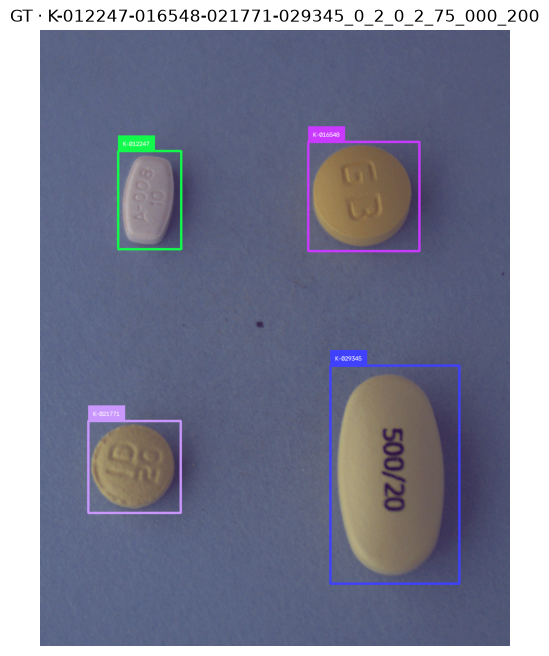

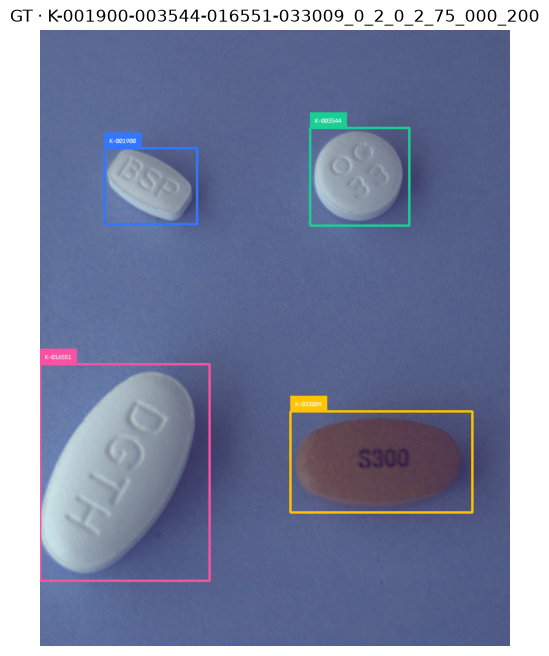

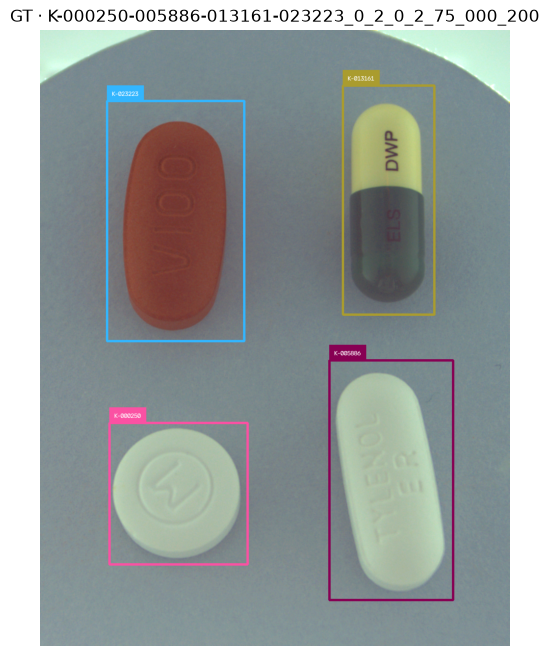

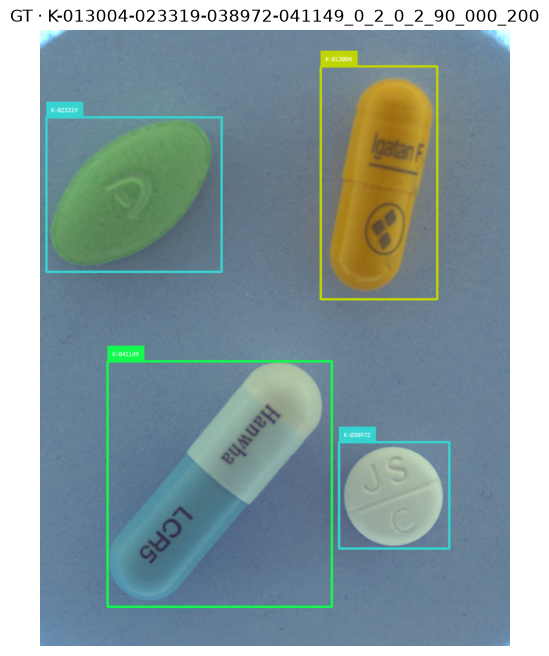

In [ ]:
def validate_yolo_labels(split_name: str, expected_stems: list[str]):
    image_dir, label_dir = YOLO_ROOT / "images" / split_name, YOLO_ROOT / "labels" / split_name
    images = list_images(image_dir)
    labels = sorted(label_dir.glob("*.txt"))
    assert len(images) == len(expected_stems) == len(labels), (len(images), len(labels), len(expected_stems))
    class_ids = []
    for path in labels:
        rows = [line.split() for line in path.read_text(encoding="utf-8").splitlines() if line.strip()]
        if not rows: raise RuntimeError(f"빈 label 파일: {path}")
        for row in rows:
            if len(row) != 5: raise RuntimeError(f"YOLO 열 수 오류: {path}: {row}")
            cls, *values = row
            class_ids.append(int(cls)); values = [float(v) for v in values]
            if not (0 <= int(cls) < num_classes and all(0 <= v <= 1 for v in values)):
                raise RuntimeError(f"YOLO 범위 오류: {path}: {row}")
    print(f"{split_name:>5}: images={len(images):,}, labels={len(labels):,}, boxes={len(class_ids):,}")

validate_yolo_labels("train", train_stems)
validate_yolo_labels("val", valid_stems)

def show_ground_truth(stem, figsize=(10, 8)):
    record = image_records[stem]
    image = np.asarray(Image.open(record["image_path"]).convert("RGB")).copy()
    xyxy = np.array([[x, y, x + w, y + h] for x,y,w,h in (a["bbox"] for a in record["annotations"])], dtype=float)
    class_id = np.array([code_to_model_id[a["category_code"]] for a in record["annotations"]], dtype=int)
    det = sv.Detections(xyxy=xyxy, class_id=class_id)
    labels = [f"{model_id_to_code[c]}" for c in class_id]
    canvas = sv.BoxAnnotator(thickness=3).annotate(image, det)
    canvas = sv.LabelAnnotator(text_scale=.45).annotate(canvas, det, labels)
    plt.figure(figsize=figsize); plt.imshow(canvas); plt.title(f"GT · {stem}"); plt.axis("off"); plt.show()

for sample_stem in random.sample(valid_stems, min(4, len(valid_stems))): show_ground_truth(sample_stem)

## 9. 50 iteration 속도 시험 (필수 권장)

`RUN_SPEED_TEST=True`일 때 약 50 training iteration만 수행하고 validation은 생략합니다. 이 결과로 30 epoch 예상 시간을 출력합니다.

- 예상 시간이 5시간 이하면 설정 그대로 학습합니다.
- 5시간을 넘으면 `MODEL_WEIGHTS="yolo26n.pt"`로 낮추거나, `IMGSZ=448`로 낮춘 뒤 속도 시험을 다시 합니다.


In [ ]:
if RUN_SPEED_TEST:
    speed_fraction = min(1.0, (50 * BATCH) / len(train_stems))
    speed_model = YOLO(MODEL_WEIGHTS)
    speed_start = time.perf_counter()
    speed_model.train(
        data=str(DATA_YAML), epochs=1, fraction=speed_fraction, imgsz=IMGSZ, batch=BATCH, nbs=NBS,
        device=0, workers=NUM_WORKERS, amp=AMP, deterministic=True, val=False, cache=False,
        project=str(PROJECT_DIR), name=f"{RUN_NAME}_speed50", exist_ok=False,
        save=False, plots=False, verbose=False,
        optimizer="auto", seed=SEED,
        degrees=0.0, translate=0.05, scale=0.10, shear=0.0, perspective=0.0,
        flipud=0.0, fliplr=0.5, mosaic=0.0, mixup=0.0,
    )
    speed_seconds = time.perf_counter() - speed_start
    estimated_train_batches = math.ceil(len(train_stems) / BATCH)
    # 초기 모델 준비 시간을 제외하지 못하므로 보수적으로 validation 오버헤드 20%를 더합니다.
    seconds_per_iteration = speed_seconds / 50
    estimated_total_hours = seconds_per_iteration * estimated_train_batches * EPOCHS * 1.20 / 3600
    print(f"50 iteration wall time: {speed_seconds:.1f}초")
    print(f"추정 학습 batch/epoch: {estimated_train_batches:,}")
    print(f"30 epoch 보수적 예상: {estimated_total_hours:.2f}시간 (validation 20% 포함)")
    if estimated_total_hours > 5:
        print("5시간 초과 예상 → yolo26n.pt 또는 IMGSZ=448로 속도 시험을 다시 하세요.")
    else:
        print("5시간 목표 통과 → RUN_SPEED_TEST=False, RUN_TRAINING=True로 바꿔 학습하세요.")
    del speed_model
    gc.collect(); torch.cuda.empty_cache()
else:
    print("RUN_SPEED_TEST=False: 속도 시험 생략")


RUN_SPEED_TEST=False: 속도 시험 생략


## 10. Epoch별 Loss · 대회 mAP 출력 설정

기본 validation이 계산한 클래스별 AP 배열(0.50, 0.55, …, 0.95)에서 0.75~0.95 다섯 칸만 평균합니다. 따라서 매 epoch마다 validation 추론을 추가로 한 번 더 하지 않습니다.

표시 형식: `Epoch 01/30 | Loss: 12.34567 | mAP@[0.75:0.95]: 0.12345`


In [ ]:
train_loss_hist = []
val_map_hist = []
val_epoch_hist = []
BEST_COMPETITION_MAP = -float("inf")
EPOCH_SUMMARY_PATH = OUTPUT_DIR / "epoch_summary.csv"

def _as_float(value):
    return float(value.detach().cpu()) if hasattr(value, "detach") else float(value)

def _competition_map_from_validator(trainer):
    # Ultralytics YOLO detection validator: IoU axis = [.50, .55, ..., .95].
    all_ap = np.asarray(trainer.validator.metrics.box.all_ap, dtype=float)
    if all_ap.ndim != 2 or all_ap.shape[1] < 10:
        raise RuntimeError(f"예상하지 못한 Ultralytics AP 배열 형태: {all_ap.shape}")
    return float(np.nanmean(all_ap[:, 5:10]))  # .75, .80, .85, .90, .95

def report_competition_epoch(trainer):
    """기본 validation 직후 1회 실행: 화면에는 요청한 두 지표만 출력."""
    global BEST_COMPETITION_MAP, EPOCH_SUMMARY_PATH

    if trainer.tloss is None:
        return
    loss_values = trainer.tloss.values() if isinstance(trainer.tloss, dict) else trainer.tloss
    train_loss = sum(_as_float(value) for value in loss_values)
    competition_map = _competition_map_from_validator(trainer)
    epoch_number = int(trainer.epoch) + 1

    train_loss_hist.append(train_loss)
    val_map_hist.append(competition_map)
    val_epoch_hist.append(epoch_number)

    # Ultralytics가 실제 생성한 현재 실행 폴더를 기준으로 저장
    EPOCH_SUMMARY_PATH = Path(trainer.save_dir) / "epoch_summary.csv"
    EPOCH_SUMMARY_PATH.parent.mkdir(parents=True, exist_ok=True)

    pd.DataFrame({
        "epoch": val_epoch_hist,
        "train_loss": train_loss_hist,
        "map_75_95": val_map_hist,
    }).to_csv(EPOCH_SUMMARY_PATH, index=False)

    if USE_WANDB and run is not None:
        learning_rate = trainer.optimizer.param_groups[0]["lr"]

        wandb.log(
            {
                "epoch": epoch_number,
                "train/loss": train_loss,
                "validation/mAP_75_95": competition_map,
                "learning_rate": learning_rate,
            },
            step=epoch_number,
        )

    # trainer.last는 이 callback보다 앞서 현재 epoch EMA checkpoint로 저장되어 있습니다.
    if competition_map > BEST_COMPETITION_MAP:
        BEST_COMPETITION_MAP = competition_map
        shutil.copy2(trainer.last, trainer.wdir / "best_competition_map.pt")

    print(
        f"Epoch {epoch_number:02d}/{trainer.epochs} | "
        f"Loss: {train_loss:.5f} | "
        f"mAP@[0.75:0.95]: {competition_map:.5f}"
    )

class _SilentTQDM:
    """Ultralytics batch progress bar를 감춰 epoch 요약만 남깁니다."""
    def __init__(self, iterable, *args, **kwargs):
        self.iterable = iterable
    def __iter__(self):
        return iter(self.iterable)
    def set_description(self, *args, **kwargs):
        pass
    def close(self):
        pass

def configure_quiet_epoch_log():
    if QUIET_EPOCH_LOG:
        # batch loss/progress/기본 COCO mAP 출력을 감추고 위 callback만 보입니다.
        from ultralytics.utils import LOGGER
        import ultralytics.engine.trainer as ultralytics_trainer
        LOGGER.setLevel(logging.ERROR)
        ultralytics_trainer.TQDM = _SilentTQDM


## 11. 학습

YOLO26s COCO pretrained weight를 118개 클래스에 fine-tuning합니다.

- `optimizer="auto"`로 YOLO26의 권장 optimizer를 사용합니다.
- synthetic family를 train/val에 분리했으므로 mosaic·mixup은 끕니다.
- 기본 validation은 매 epoch 한 번만 수행하고, 출력은 아래 callback의 `Loss`와 `mAP@[0.75:0.95]`만 남깁니다.


In [ ]:
#@title W&B 실험 시작

run = None

if USE_WANDB:
    run = wandb.init(
        entity=WANDB_ENTITY,
        project=WANDB_PROJECT,
        name=WANDB_RUN_NAME,
        job_type="train",
        config={
            "model": MODEL_WEIGHTS,
            "epochs": EPOCHS,
            "imgsz": IMGSZ,
            "batch_size": BATCH,
            "nbs": NBS,
            "num_classes": EXPECTED_NUM_CLASSES,
            "val_ratio": VAL_RATIO,
            "seed": SEED,
            "amp": AMP,
            "workers": NUM_WORKERS,
            "competition_ious": COMPETITION_IOUS,
        }
    )

In [ ]:
if RUN_TRAINING:
    if OUTPUT_DIR.exists() and any(OUTPUT_DIR.iterdir()):
        raise RuntimeError(f"기존 실행 폴더가 있습니다: {OUTPUT_DIR}. 새 실험이면 RUN_NAME을 바꾸세요.")

    model = YOLO(MODEL_WEIGHTS)
    model.add_callback("on_fit_epoch_end", report_competition_epoch)

    train_start = time.perf_counter()
    train_results = model.train(
        data=str(DATA_YAML), epochs=EPOCHS, imgsz=IMGSZ, batch=BATCH, nbs=NBS,
        device=0, workers=NUM_WORKERS, amp=AMP, deterministic=True,
        optimizer="auto", cos_lr=True, warmup_epochs=1.0,
        project=str(PROJECT_DIR), name=RUN_NAME, exist_ok=False,
        pretrained=True, cache=False, patience=0, save=True, save_period=5, val=True,
        plots=False, verbose=True, seed=SEED,
        degrees=0.0, translate=0.05, scale=0.10, shear=0.0, perspective=0.0,
        flipud=0.0, fliplr=0.5, mosaic=0.0, mixup=0.0, erasing=0.0,
        close_mosaic=0,
    )
    print(f"학습 소요 시간: {(time.perf_counter() - train_start)/3600:.2f}시간")
elif RESUME:
    last_pt = OUTPUT_DIR / "weights" / "last.pt"
    if not last_pt.exists():
        raise FileNotFoundError(last_pt)
    model = YOLO(str(last_pt))
    model.add_callback("on_fit_epoch_end", report_competition_epoch)
    train_results = model.train(resume=True)
else:
    print("학습 생략: 기존 best.pt를 다음 셀에서 사용합니다.")


Ultralytics 8.4.157  Python-3.11.9 torch-2.1.0+cu121 CUDA:0 (NVIDIA GeForce GTX 1070, 8192MiB)
engine\trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=0, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=C:\Users\yiydg\.cache\kagglehub\competitions\ai14-level-project\sprint_ai_project1_data\yolo26s_yolo_grouped_seed44_val20\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.0, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, mod

## 12. best checkpoint 로드 · 기본 COCO 평가


In [ ]:
RUN_OUTPUT_DIR = Path(model.trainer.save_dir)

BEST_CHECKPOINT = RUN_OUTPUT_DIR / "weights" / "best_competition_map.pt"
if not BEST_CHECKPOINT.exists():
    BEST_CHECKPOINT = RUN_OUTPUT_DIR / "weights" / "best.pt"

if not BEST_CHECKPOINT.exists():
    raise FileNotFoundError(BEST_CHECKPOINT)

gc.collect()
torch.cuda.empty_cache()

best_model = YOLO(str(BEST_CHECKPOINT))

official_eval = best_model.val(
    data=str(DATA_YAML), imgsz=IMGSZ, batch=BATCH, device=0, workers=NUM_WORKERS,
    amp=AMP, split="val", plots=True, max_det=EVAL_MAX_DETECTIONS, verbose=True,
)
print(f"COCO mAP@[.50:.95]: {official_eval.box.map:.5f}")
print(f"COCO mAP@.50      : {official_eval.box.map50:.5f}")


Ultralytics 8.4.157  Python-3.11.9 torch-2.1.0+cu121 CUDA:0 (NVIDIA GeForce GTX 1070, 8192MiB)
YOLO26s summary (fused): 120 layers, 9,510,846 parameters, 0 gradients, 21.0 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 2090.8410.7 MB/s, size: 1720.4 KB)
val: Scanning C:\Users\yiydg\.cache\kagglehub\competitions\ai14-level-project\sprint_ai_project1_data\yolo26s_yolo_grouped_seed44_val20\labels\val.cache... 1968 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1968/1968  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 246/246 3.5it/s 1:110.3sss
                   all       1968       7533      0.997      0.998      0.995      0.991
K-000250 | ()         87         87      0.999          1      0.995      0.995
K-000573 |  300mg/PTP         79         79      0.999          1      0.995      0.995
K-001866 | ()(:)         87         87      0.999          1      0.995      0.992
 K-001900 |  5mg         26       

In [ ]:
#@title 최고 모델 및 최종 평가 결과를 W&B에 기록

if USE_WANDB and run is not None:

    # 최종 best model 평가 결과 기록
    wandb.log({
        "final/coco_mAP_50_95": float(official_eval.box.map),
        "final/coco_mAP_50": float(official_eval.box.map50),
        "final/best_competition_mAP_75_95": float(BEST_COMPETITION_MAP),
    })

    # Best model Artifact
    model_artifact = wandb.Artifact(
        name=f"yolo26s-{run.id}",
        type="model",
        description=f"Best checkpoint from {WANDB_RUN_NAME}",
        metadata={
            "model": MODEL_WEIGHTS,
            "epochs": EPOCHS,
            "imgsz": IMGSZ,
            "batch_size": BATCH,
            "nbs": NBS,
            "num_classes": EXPECTED_NUM_CLASSES,
            "val_ratio": VAL_RATIO,
            "seed": SEED,
            "amp": AMP,
            "best_map_75_95": BEST_COMPETITION_MAP,
        }
    )

    model_artifact.add_file(str(BEST_CHECKPOINT))

    run.log_artifact(
        model_artifact,
        aliases=["best"]
    )

    run.finish()

    print("YOLO26S 실험 및 Artifact 업로드 완료")

## 12. 대회 지표 mAP@[0.75:0.95] 직접 계산

In [ ]:
competition_metric = MeanAveragePrecision(box_format="xyxy", iou_type="bbox", iou_thresholds=COMPETITION_IOUS, max_detection_thresholds=[1, 10, EVAL_MAX_DETECTIONS], class_metrics=False, backend="faster_coco_eval")
submission_cap_metric = MeanAveragePrecision(box_format="xyxy", iou_type="bbox", iou_thresholds=COMPETITION_IOUS, max_detection_thresholds=[1, 5, SUBMISSION_MAX_DETECTIONS], class_metrics=False, backend="faster_coco_eval")

def batched(items, batch_size):
    for start in range(0, len(items), batch_size): yield items[start:start + batch_size]

for stem_batch in tqdm(list(batched(valid_stems, PRED_BATCH_SIZE)), desc="Competition mAP"):
    paths = [str(image_records[stem]["image_path"]) for stem in stem_batch]
    results = best_model.predict(paths, imgsz=IMGSZ, conf=PRED_CONFIDENCE, max_det=EVAL_MAX_DETECTIONS, device=0, verbose=False)
    preds, cap_preds, targets = [], [], []
    for stem, result in zip(stem_batch, results):
        boxes = result.boxes
        xyxy = boxes.xyxy.detach().cpu()
        scores = boxes.conf.detach().cpu()
        labels = boxes.cls.detach().cpu().to(torch.int64)
        order = torch.argsort(scores, descending=True)
        preds.append({"boxes": xyxy[order], "scores": scores[order], "labels": labels[order]})
        cap_order = order[:SUBMISSION_MAX_DETECTIONS]
        cap_preds.append({"boxes": xyxy[cap_order], "scores": scores[cap_order], "labels": labels[cap_order]})
        target_boxes = torch.tensor([[x,y,x+w,y+h] for x,y,w,h in (a["bbox"] for a in image_records[stem]["annotations"])], dtype=torch.float32)
        target_labels = torch.tensor([code_to_model_id[a["category_code"]] for a in image_records[stem]["annotations"]], dtype=torch.int64)
        targets.append({"boxes": target_boxes, "labels": target_labels})
    competition_metric.update(preds, targets); submission_cap_metric.update(cap_preds, targets)

competition_map = competition_metric.compute()["map"].item()
submission_cap_map = submission_cap_metric.compute()["map"].item()
print(f"Competition mAP@[.75:.95] (max {EVAL_MAX_DETECTIONS}): {competition_map:.5f}")
print(f"Submission-cap mAP@[.75:.95] (max {SUBMISSION_MAX_DETECTIONS}): {submission_cap_map:.5f}")

Competition mAP:   0%|          | 0/492 [00:00<?, ?it/s]

Competition mAP@[.75:.95] (max 20): 0.98880
Submission-cap mAP@[.75:.95] (max 8): 0.98880


## 13. validation 예측 시각화

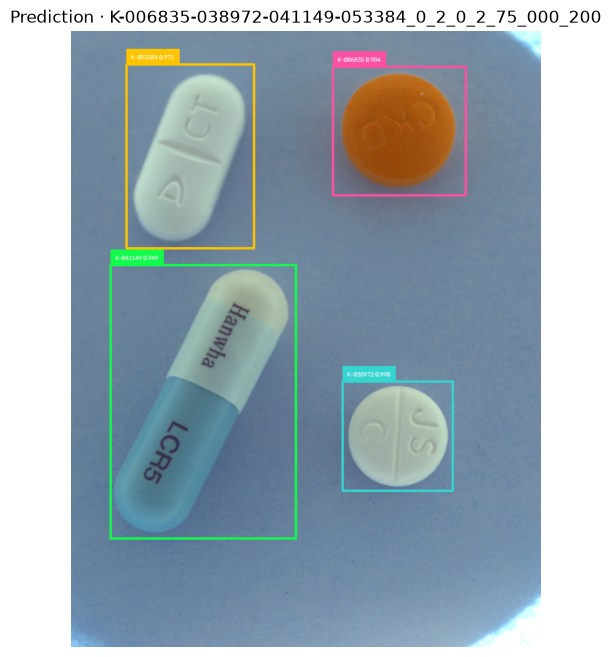

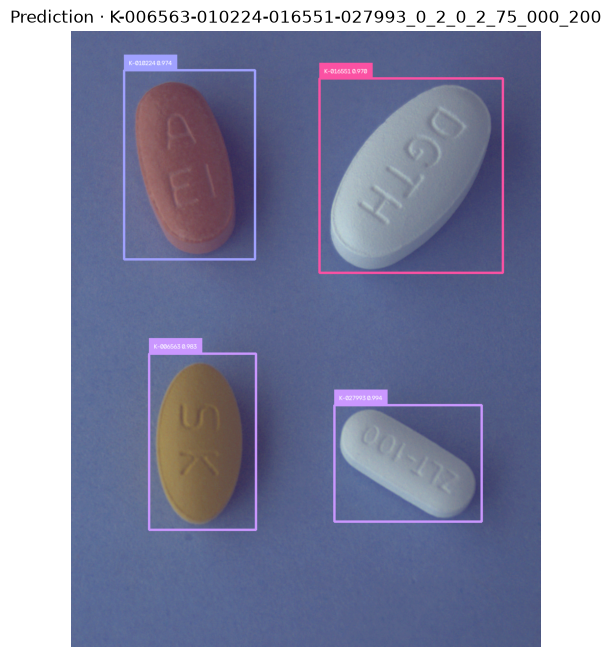

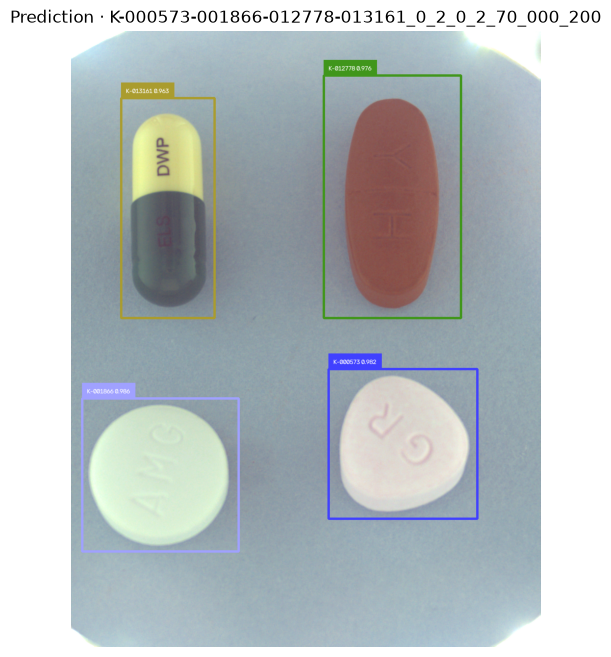

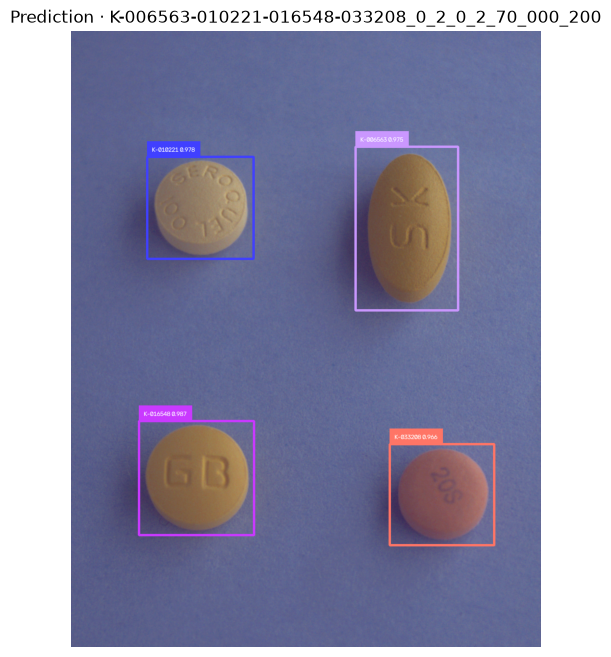

In [ ]:
def show_prediction(stem, threshold=.20, figsize=(10, 8)):
    image = Image.open(image_records[stem]["image_path"]).convert("RGB")
    result = best_model.predict(str(image_records[stem]["image_path"]), imgsz=IMGSZ, conf=threshold, max_det=EVAL_MAX_DETECTIONS, device=0, verbose=False)[0]
    boxes = result.boxes
    det = sv.Detections(xyxy=boxes.xyxy.cpu().numpy(), confidence=boxes.conf.cpu().numpy(), class_id=boxes.cls.cpu().numpy().astype(int))
    labels = [f"{model_id_to_code[int(c)]} {s:.3f}" for c,s in zip(det.class_id, det.confidence)]
    canvas = sv.BoxAnnotator(thickness=3).annotate(np.asarray(image).copy(), det)
    canvas = sv.LabelAnnotator(text_scale=.45).annotate(canvas, det, labels)
    plt.figure(figsize=figsize); plt.imshow(canvas); plt.title(f"Prediction · {stem}"); plt.axis("off"); plt.show(); image.close()

for sample_stem in random.sample(valid_stems, min(4, len(valid_stems))): show_prediction(sample_stem)

## 14. 테스트 추론 · 제출 CSV 생성

In [ ]:
# 수정 후
RUN_OUTPUT_DIR = BEST_CHECKPOINT.parent.parent  # .../실행폴더/weights/best.pt → 실행폴더
RUN_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SUBMISSION_PATH = RUN_OUTPUT_DIR / "submission_yolo26s.csv"

rows, annotation_id = [], 1

for path_batch in tqdm(list(batched(test_paths, PRED_BATCH_SIZE)), desc="Test inference"):
    results = best_model.predict([str(p) for p in path_batch], imgsz=IMGSZ, conf=PRED_CONFIDENCE, max_det=SUBMISSION_MAX_DETECTIONS, device=0, verbose=False)
    for image_path, result in zip(path_batch, results):
        try: image_id = int(image_path.stem)
        except ValueError as exc: raise ValueError(f"test filename stem이 숫자가 아닙니다: {image_path.stem!r}") from exc
        image_w, image_h = result.orig_shape[1], result.orig_shape[0]
        boxes = result.boxes
        order = torch.argsort(boxes.conf.detach().cpu(), descending=True)[:SUBMISSION_MAX_DETECTIONS]
        for idx in order.tolist():
            x1,y1,x2,y2 = map(float, boxes.xyxy[idx].detach().cpu().tolist())
            x1, y1 = max(0., min(x1, image_w)), max(0., min(y1, image_h))
            x2, y2 = max(0., min(x2, image_w)), max(0., min(y2, image_h))
            bw, bh = x2-x1, y2-y1
            if bw <= 0 or bh <= 0: continue
            class_id = int(boxes.cls[idx].item())
            rows.append({"annotation_id": annotation_id, "image_id": image_id, "category_id": code_to_submission_id[model_id_to_code[class_id]], "bbox_x": x1, "bbox_y": y1, "bbox_w": bw, "bbox_h": bh, "score": float(boxes.conf[idx].item())})
            annotation_id += 1

submission_columns = ["annotation_id", "image_id", "category_id", "bbox_x", "bbox_y", "bbox_w", "bbox_h", "score"]
submission = pd.DataFrame(rows, columns=submission_columns)
submission.to_csv(SUBMISSION_PATH, index=False)
print(f"저장 완료: {SUBMISSION_PATH.resolve()} / rows={len(submission):,}")
display(submission.head())


Test inference:   0%|          | 0/211 [00:00<?, ?it/s]

저장 완료: C:\Users\yiydg\Desktop\Vault_home\Projects(Work)\Sprint AI_14기\workspace\runs\detect\beginner-team-project\yolo26s_pills_512_b8_e30_grouped-9\submission_yolo26s.csv / rows=4,047


,annotation_id,image_id,category_id,bbox_x,bbox_y,bbox_w,bbox_h,score
0,1,1,1900,157.180206,250.422058,204.316376,126.431854,0.986325
1,2,1,27926,598.874390,672.113281,256.085449,482.699585,0.982230
2,3,1,16551,555.709961,73.493843,397.836792,399.912987,0.979135
3,4,1,24850,170.583313,740.767334,184.477783,291.283325,0.977325
4,5,1,12247,155.744751,250.728531,207.834167,125.762558,0.001238


## 15. 제출 파일 검증

In [ ]:
assert submission.columns.tolist() == submission_columns
assert submission["annotation_id"].is_unique
assert (submission["bbox_w"] > 0).all() and (submission["bbox_h"] > 0).all()
assert submission["score"].between(0, 1).all()
assert set(submission["category_id"]).issubset(set(code_to_submission_id.values()))

test_image_ids = {int(path.stem) for path in test_paths}
prediction_counts = submission.groupby("image_id").size()
missing_prediction_ids = test_image_ids - set(prediction_counts.index)
print(f"제출 대상 이미지 수: {len(test_image_ids):,}")
print(f"예측 포함 이미지 수: {prediction_counts.size:,}")
print(f"예측 0개 test 이미지: {len(missing_prediction_ids)}")
display(prediction_counts.describe())
if missing_prediction_ids: raise RuntimeError(f"예측이 0개인 test 이미지: {sorted(missing_prediction_ids)[:20]}")

제출 대상 이미지 수: 842
예측 포함 이미지 수: 842
예측 0개 test 이미지: 0


count    842.000000
mean       4.806413
std        1.113876
min        3.000000
25%        4.000000
50%        5.000000
75%        5.000000
max        8.000000
dtype: float64

## 운영 메모

1. 처음에는 `RUN_SPEED_TEST=True`, `RUN_TRAINING=False`로 약 50 iteration을 측정합니다.
2. 예상 시간이 5시간 이하면 `RUN_SPEED_TEST=False`, `RUN_TRAINING=True`로 바꾸어 **30 epoch** 학습을 시작합니다.
3. GTX 1070에서 batch 8이 OOM이면 `BATCH=6`으로 낮추고 `NBS=64`는 그대로 둡니다. 5시간을 넘으면 먼저 `yolo26n.pt` 또는 `IMGSZ=448`을 검토합니다.
4. 모델 비교는 Ultralytics 기본 COCO mAP가 아니라 `mAP@[0.75:0.95]`와 `submission-cap mAP@[0.75:0.95]`를 기준으로 합니다.
5. 수동 중단 후에는 `RESUME=True`, `RUN_TRAINING=False`로 바꾸어 같은 `last.pt`에서 이어갑니다.
